In [ ]:
import os
import pandas as pd
import numpy as np

BASE_DIR = os.path.dirname(__file__)
CSV_DIR = os.path.join(BASE_DIR, "csv_files")

def csv_in(name: str) -> str:
    p = os.path.join(CSV_DIR, name)
    if not os.path.exists(p):
        raise FileNotFoundError(f"CSV not found: {p}")
    return p

def csv_out(name: str) -> str:
    return os.path.join(CSV_DIR, name)

mix_df = pd.read_csv(csv_in("Mix.csv"))
hs_df = pd.read_csv(csv_in("HS.csv"))
ls_df = pd.read_csv(csv_in("LS.csv"))

all_data = []

def get_label(condition):
    if str(condition).strip().lower() == 'normal':
        return 'Normal'
    return 'Pathology'

for _, row in hs_df.iterrows():
    sid = str(row['Heart Sound ID']).strip()
    all_data.append({
        'filename': f"HS/{sid}.wav",
        'label': get_label(row['Heart Sound Type']),
        'source': 'HS',
        'modality': 'HS',
        'sound_id': sid,
    })

for _, row in ls_df.iterrows():
    sid = str(row['Lung Sound ID']).strip()
    all_data.append({
        'filename': f"LS/{sid}.wav",
        'label': get_label(row['Lung Sound Type']),
        'source': 'LS',
        'modality': 'LS',
        'sound_id': sid,
    })

for _, row in mix_df.iterrows():
    hs_id = str(row['Heart Sound ID']).strip()
    ls_id = str(row['Lung Sound ID']).strip()

    all_data.append({
        'filename': f"MIX/{hs_id}.wav",
        'label': get_label(row['Heart Sound Type']),
        'source': 'MIX',
        'modality': 'HS',
        'sound_id': hs_id,
    })
    all_data.append({
        'filename': f"MIX/{ls_id}.wav",
        'label': get_label(row['Lung Sound Type']),
        'source': 'MIX',
        'modality': 'LS',
        'sound_id': ls_id,
    })

full_df = pd.DataFrame(all_data).sample(frac=1, random_state=42).reset_index(drop=True)

n = len(full_df)
train_end = int(n * 0.7)
val_end = int(n * 0.8)

train_df = full_df.iloc[:train_end]
val_df = full_df.iloc[train_end:val_end]
test_df = full_df.iloc[val_end:]

train_df.to_csv(csv_out("train_partial.csv"), index=False)
val_df.to_csv(csv_out("val_partial.csv"), index=False)
test_df.to_csv(csv_out("test_partial.csv"), index=False)

print(f"Files created: Train_partial ({len(train_df)}), Va_partiall ({len(val_df)}), Test_partial ({len(test_df)})")
print("\nPreview of train.csv:")
print(train_df[['filename', 'label', 'source', 'modality', 'sound_id']].head())

In [ ]:
import pandas as pd
import os

BASE_PATH = os.path.dirname(__file__)
CSV_DIR = os.path.join(BASE_PATH, 'csv_files')

train_df = pd.read_csv(os.path.join(CSV_DIR, 'train_partial.csv'))
val_df = pd.read_csv(os.path.join(CSV_DIR, 'val_partial.csv'))
test_df = pd.read_csv(os.path.join(CSV_DIR, 'test_partial.csv'))

mix_meta_df = pd.read_csv(os.path.join(CSV_DIR, 'Mix.csv'))
hs_meta_df = pd.read_csv(os.path.join(CSV_DIR, 'HS.csv'))
ls_meta_df = pd.read_csv(os.path.join(CSV_DIR, 'LS.csv'))

def annotate_df(df: pd.DataFrame) -> pd.DataFrame:
    hs_meta = hs_meta_df.copy()
    ls_meta = ls_meta_df.copy()
    mix_meta = mix_meta_df.copy()
    for col in ("Heart Sound ID", "Lung Sound ID"):
        if col in hs_meta.columns:
            hs_meta[col] = hs_meta[col].astype(str).str.strip()
        if col in ls_meta.columns:
            ls_meta[col] = ls_meta[col].astype(str).str.strip()
        if col in mix_meta.columns:
            mix_meta[col] = mix_meta[col].astype(str).str.strip()

    out_sound, out_loc, out_gender, out_id = [], [], [], []

    for _, row in df.iterrows():
        sound = "NA"
        gender = "NA"
        location = "NA"
        sound_id = "NA"

        type_ = str(row.get("source", "")).strip()
        filename = str(row.get("filename", "")).strip()

        parts = filename.split("/")
        clean_id = (parts[1] if len(parts) > 1 else parts[0]).replace(".wav", "").strip()

        if type_ == "MIX":
            m = mix_meta[mix_meta["Lung Sound ID"] == clean_id]
            if not m.empty:
                gender = str(m.iloc[0]["Gender"]).strip()
                sound = str(m.iloc[0]["Lung Sound Type"]).strip()
                location = str(m.iloc[0]["Location"]).strip()
                sound_id = str(m.iloc[0]["Lung Sound ID"]).strip()

            m = mix_meta[mix_meta["Heart Sound ID"] == clean_id]
            if not m.empty:
                gender = str(m.iloc[0]["Gender"]).strip()
                sound = str(m.iloc[0]["Heart Sound Type"]).strip()
                location = str(m.iloc[0]["Location"]).strip()
                sound_id = str(m.iloc[0]["Heart Sound ID"]).strip()

        elif type_ == "HS":
            m = hs_meta[hs_meta["Heart Sound ID"] == clean_id]
            if not m.empty:
                gender = str(m.iloc[0]["Gender"]).strip()
                sound = str(m.iloc[0]["Heart Sound Type"]).strip()
                location = str(m.iloc[0]["Location"]).strip()
                sound_id = str(m.iloc[0]["Heart Sound ID"]).strip()
            else:
                m = mix_meta[mix_meta["Heart Sound ID"] == clean_id]
                if not m.empty:
                    gender = str(m.iloc[0]["Gender"]).strip()
                    sound = str(m.iloc[0]["Heart Sound Type"]).strip()
                    location = str(m.iloc[0]["Location"]).strip()
                    sound_id = str(m.iloc[0]["Heart Sound ID"]).strip()

        elif type_ == "LS":
            m = ls_meta[ls_meta["Lung Sound ID"] == clean_id]
            if not m.empty:
                gender = str(m.iloc[0]["Gender"]).strip()
                sound = str(m.iloc[0]["Lung Sound Type"]).strip()
                location = str(m.iloc[0]["Location"]).strip()
                sound_id = str(m.iloc[0]["Lung Sound ID"]).strip()
            else:
                m = mix_meta[mix_meta["Lung Sound ID"] == clean_id]
                if not m.empty:
                    gender = str(m.iloc[0]["Gender"]).strip()
                    sound = str(m.iloc[0]["Lung Sound Type"]).strip()
                    location = str(m.iloc[0]["Location"]).strip()
                    sound_id = str(m.iloc[0]["Lung Sound ID"]).strip()

        out_id.append(sound_id)
        out_sound.append(sound)
        out_loc.append(location)
        out_gender.append(gender)

    df = df.copy()
    df["sound"] = out_sound
    df["body_location"] = out_loc
    df["patient_gender"] = out_gender
    df["sound id"] = out_id
    return df

train_df = annotate_df(train_df)
val_df = annotate_df(val_df)
test_df = annotate_df(test_df)

train_df.to_csv(os.path.join(CSV_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(CSV_DIR, 'val.csv'), index=False)
test_df.to_csv(os.path.join(CSV_DIR, 'test.csv'), index=False)

CSV jak sie tworzy

In [ ]:
import os
import sys
sys.dont_write_bytecode = True
os.environ['NUMBA_CACHE_DIR'] = os.path.join(os.getcwd(), 'numba_cache')
from matplotlib.colors import LogNorm
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

import pywt
BASE_PATH=os.getcwd()
OUTPUT_DIR = os.path.join(BASE_PATH, 'Images')
CSV_FILE_FULL_PATH = os.path.join(BASE_PATH, 'csv_files/train.csv') 
"""""
F_LOW = 100.0  
F_HIGH = 1500.0 
FILTER_ORDER = 4 
"""
#Filtry jednak nie potrzebne
"""""
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y_filtered = filtfilt(b, a, data)
    return y_filtered
"""
#Wizualizacje
def extract_features_for_csv(y):
    coeffs = pywt.wavedec(y, 'db4', level=5)
    cechy=[]
    for c in coeffs:
        mav=np.mean(np.abs(c))
        cechy.append(mav)
    return cechy
def plot_scalogram(y,fs,title_prefix,duration=5):
        time_limit = int(fs * duration)
        if len(y) > time_limit:
            y = y[:time_limit]
        scales = np.arange(1, 128)   
        coeffs, freqs = pywt.cwt(y, scales, 'morl', sampling_period=1/fs)
        power = np.abs(coeffs)
        plt.figure(figsize=(10, 6))
        time_duration = len(y) / fs
        plt.imshow(power, 
               extent=[0, time_duration, 1, 128],
               aspect='auto', 
               cmap='jet', 
               norm=LogNorm(vmin=power.min() + 1e-6, vmax=power.max()),
               origin='lower')          
        plt.colorbar(label='Energia')
        plt.title(f'{title_prefix}_Skalogram Falkowy (Morlet)')
        plt.xlabel('Czas (s)')
        plt.ylabel('Skala (częstotliwość)')
        save_path_fft = os.path.join(OUTPUT_DIR, f'{title_prefix}_skalogram.png')
        plt.savefig(save_path_fft) 
        plt.close()

        
def analyze_and_plot_signal(y, fs, title_prefix, filename):
    
    # ANALIZA CZĘSTOTLIWOŚCIOWA (FFT)
    N = len(y)
    Y = np.fft.fft(y)
    Y_abs = np.abs(Y) / N
    f = np.fft.fftfreq(N, 1/fs)
    jednostronne_index = np.where(f >= 0)
    f_jednostronne = f[jednostronne_index]
    Y_jednostronne = Y_abs[jednostronne_index]
    Y_jednostronne[1:] = 2 * Y_jednostronne[1:]

    # Wizualizacja Widma Amplitudowego (FFT)
    plt.figure(figsize=(10, 5))
    plt.plot(f_jednostronne, Y_jednostronne)
    plt.title(f'{title_prefix}: Widmo Amplitudowe (FFT)')
    plt.xlabel('Częstotliwość (Hz)')
    plt.ylabel('Amplituda (Normalizowana)')
    plt.xlim(0, fs / 2)
    plt.grid(True)
    plt.tight_layout()
    save_path_fft = os.path.join(OUTPUT_DIR, f'{title_prefix}_FFT.png')
    plt.savefig(save_path_fft)
    plt.close()

    #. WIZUALIZACJA SPEKTROGRAMÓW 
    S = librosa.stft(y)
    S_dB = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, sr=fs, x_axis='time', y_axis='hz', cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'{title_prefix}: Spektrogram ')
    plt.ylim(0, 2000) 
    plt.tight_layout()
    save_path_fft = os.path.join(OUTPUT_DIR, f'{title_prefix}_spektogram.png')
    plt.savefig(save_path_fft) 
    plt.close()

# Wczytanie CSV z pełnej ścieżki
try:
    df_train = pd.read_csv(CSV_FILE_FULL_PATH) 
    print(f"Sukces: Wczytano {len(df_train)} rekordów z {CSV_FILE_FULL_PATH}")
except FileNotFoundError:
    print(f"BŁĄD KRYTYCZNY: Nie znaleziono pliku CSV: {CSV_FILE_FULL_PATH}. Sprawdź, czy plik jest w folderze PROJEKT.")
    exit()

# Wybór po jednym reprezentatywnym pliku z każdej klasy
try:
    lung_pathology = df_train[(df_train['label'] == 'Pathology') & (df_train['source'] == 'MIX')& (df_train['sound id'].str.replace(r'[^A-Za-z]', '', regex=True)=='L')].iloc[0]['filename']
    lung_normal = df_train[(df_train['label'] == 'Normal') & (df_train['source'] == 'LS')].iloc[0]['filename']
    heart_pathology = df_train[(df_train['label'] == 'Pathology') & (df_train['source'] == 'HS')].iloc[0]['filename']
    heart_normal = df_train[(df_train['label'] == 'Normal') & (df_train['source'] == 'HS')].iloc[0]['filename']
except IndexError:
    print("Błąd: Nie znaleziono wystarczającej liczby próbek 'Normal' lub 'Pathology' w train.csv.")
    exit()

files_to_process = {
    'lung_pathology': lung_pathology,
    'lung_normal': lung_normal,
    'heart_pathology': heart_pathology,
    'heart_normal': heart_normal
}


print("--- Rozpoczęcie przetwarzania sygnałów ---")

for label, filename in files_to_process.items():
    # Pełna ścieżka do pliku audio
    full_path = os.path.join(BASE_PATH, 'Sound', filename)
    print(f"\nPrzetwarzanie pliku: {label} ({full_path})")
    try:
        # Wczytanie sygnału audio
        y, fs = librosa.load(full_path, sr=16000)
        print(f"  Częstotliwość próbkowania (fs): {fs} Hz. Długość sygnału: {len(y)} próbek.")
        
        # Analiza i wizualizacja
        analyze_and_plot_signal(y, fs, label, filename)
        plot_scalogram(y,fs,label)
        print(f"  Analiza zakończona. Wykresy zapisane jako: {label}_*.png")

    except FileNotFoundError:
        print(f"  BŁĄD: Nie znaleziono pliku audio: {full_path}. Sprawdź, czy ścieżka w pliku CSV ({filename}) jest poprawna względem {BASE_PATH}!")
    except Exception as e:
        print(f"  Wystąpił nieznany błąd podczas przetwarzania: {e}")

print("\n--- Przetwarzanie ZAKOŃCZONE ---")

Sukces: Wczytano 292 rekordów z c:\Users\Karol\Desktop\Analiza_HLS-CMDS\csv_files/train.csv
--- Rozpoczęcie przetwarzania sygnałów ---

Przetwarzanie pliku: lung_pathology (c:\Users\Karol\Desktop\Analiza_HLS-CMDS\Sound\MIX/L0106.wav)
  Częstotliwość próbkowania (fs): 16000 Hz. Długość sygnału: 240000 próbek.
  Analiza zakończona. Wykresy zapisane jako: lung_pathology_*.png

Przetwarzanie pliku: lung_normal (c:\Users\Karol\Desktop\Analiza_HLS-CMDS\Sound\LS/M_N_LLA.wav)
  Częstotliwość próbkowania (fs): 16000 Hz. Długość sygnału: 240000 próbek.
  Analiza zakończona. Wykresy zapisane jako: lung_normal_*.png

Przetwarzanie pliku: heart_pathology (c:\Users\Karol\Desktop\Analiza_HLS-CMDS\Sound\HS/F_MSM_A.wav)
  Częstotliwość próbkowania (fs): 16000 Hz. Długość sygnału: 240000 próbek.
  Analiza zakończona. Wykresy zapisane jako: heart_pathology_*.png

Przetwarzanie pliku: heart_normal (c:\Users\Karol\Desktop\Analiza_HLS-CMDS\Sound\HS/F_N_RC.wav)
  Częstotliwość próbkowania (fs): 16000 Hz. Długość sygnału: 240000 próbek.
  Analiza zakończona. Wykresy zapisane jako: heart_normal_*.png

--- Przetwarzanie ZAKOŃCZONE ---

1. Przetwarzanie wstępne i balansowanie zbioru danych
W pierwotnym zbiorze danych zidentyfikowano znaczny brak równowagi klasowej (85% przypadków patologicznych). Aby zapobiec biasowi modelu, zastosowano technikę Sliding Window (przesuwnego okna) o długości 2.0s z różnym krokiem (stride):

Dla klasy Normal: krok 0.5s (z zakładką), co pozwoliło na multiplikację rzadszych próbek.

Dla klasy Pathology: krok 2.0s (brak zakładki).

Efekt: Zwiększono liczebność próbek serca (HS) do 530 oraz płuc (LS) do 485, uzyskując niemal idealny balans klasowy.

In [ ]:
import os
import librosa
import soundfile as sf
import pandas as pd


def _ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def _is_normal_label(label) -> bool:
    return str(label).strip().lower() == "normal"


def segment_from_split_csv(
    csv_path: str,
    audio_root: str = "Sound",
    output_root: str = "Sound_segmented",
    win_sec: float = 2.0,
    normal_step_sec: float = 0.5,
) -> None:
    df = pd.read_csv(csv_path)

    required = {"filename", "label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV {csv_path} missing columns: {sorted(missing)}")

    # nazwa splitu: train.csv -> train, csv_files/train.csv -> train
    split_name = os.path.splitext(os.path.basename(csv_path))[0]

    new_segments = []

    print(f"[{split_name}] Przetwarzam {len(df)} plików z {csv_path}...")

    for _, row in df.iterrows():
        rel_path = str(row["filename"]).strip().replace("\\", "/")
        label_text = row["label"]
        source = str(row["source"]).strip() if "source" in df.columns else "UNKNOWN"

        input_path = os.path.join(audio_root, rel_path)

        # Mała pomoc na wypadek MIX vs Mix
        if not os.path.exists(input_path) and rel_path.startswith("MIX/"):
            input_path_alt = os.path.join(audio_root, "Mix", rel_path[len("MIX/"):])
            if os.path.exists(input_path_alt):
                input_path = input_path_alt

        if not os.path.exists(input_path):
            # plik z CSV nie istnieje na dysku -> pomijamy
            continue

        try:
            y, sr = librosa.load(input_path, sr=None)
        except Exception:
            continue

        win_len = int(win_sec * sr)
        if win_len <= 0 or len(y) < win_len:
            continue

        is_normal = _is_normal_label(label_text)
        step = int(normal_step_sec * sr) if is_normal else win_len
        if step <= 0:
            step = win_len

        out_dir = os.path.join(output_root, split_name, f"{source}_segmented")
        _ensure_dir(out_dir)

        stem = os.path.splitext(os.path.basename(rel_path))[0]

        count = 0
        for start in range(0, len(y) - win_len + 1, step):
            segment = y[start : start + win_len]
            seg_name = f"{stem}_seg_{count}.wav"
            out_path = os.path.join(out_dir, seg_name)
            sf.write(out_path, segment, sr)

            # zapisuj ścieżkę względną od output_root (wygodne do późniejszego użycia)
            seg_rel = os.path.join(split_name, f"{source}_segmented", seg_name).replace("\\", "/")
            new_segments.append(
                {
                    "filename": seg_rel,
                    "label": 0 if is_normal else 1,
                    "label_text": "Normal" if is_normal else "Pathology",
                    "source": source,
                    "original_filename": rel_path,
                }
            )
            count += 1

    out_csv = os.path.join(os.path.dirname(csv_path), f"{split_name}_segmented.csv")
    pd.DataFrame(new_segments).to_csv(out_csv, index=False)

    print(f"[{split_name}] Sukces! Stworzono {len(new_segments)} segmentów.")
    if new_segments:
        out_df = pd.DataFrame(new_segments)
        print(out_df["label"].value_counts(normalize=True))
    print("-" * 30)


if __name__ == "__main__":
    for split in ["train", "val", "test"]:
        p = os.path.join("csv_files", f"{split}.csv")
        if os.path.exists(p):
            segment_from_split_csv(p)
        else:
            print(f"Pomijam, brak pliku: {p}")

[train] Przetwarzam 273 plików z csv_files\train.csv...
[train] Sukces! Stworzono 2621 segmentów.
label
1    0.598245
0    0.401755
Name: proportion, dtype: float64
------------------------------
[val] Przetwarzam 39 plików z csv_files\val.csv...
[val] Sukces! Stworzono 372 segmentów.
label
1    0.564516
0    0.435484
Name: proportion, dtype: float64
------------------------------
[test] Przetwarzam 78 plików z csv_files\test.csv...
[test] Sukces! Stworzono 872 segmentów.
label
0    0.526376
1    0.473624
Name: proportion, dtype: float64
------------------------------


2. Klasyfikacja z wykorzystaniem Drzewa Decyzyjnego
Jako model bazowy (baseline) wybrano Drzewo Decyzyjne (Decision Tree) ze względu na jego wysoką interpretowalność. Cechy wejściowe stanowią współczynniki MFCC (Mel-frequency cepstral coefficients), które najlepiej oddają charakterystykę sygnałów medycznych.

Ekstrakcja cech z csv_files/train_segmented.csv (source=HS)...
Ekstrakcja cech z csv_files/test_segmented.csv (source=HS)...

--- WYNIKI (HS) Drzewo Decyzyjne (Zoptymalizowane) ---
              precision    recall  f1-score   support

      Normal       0.76      0.41      0.53        54
   Pathology       0.52      0.83      0.64        42

    accuracy                           0.59        96
   macro avg       0.64      0.62      0.59        96
weighted avg       0.66      0.59      0.58        96



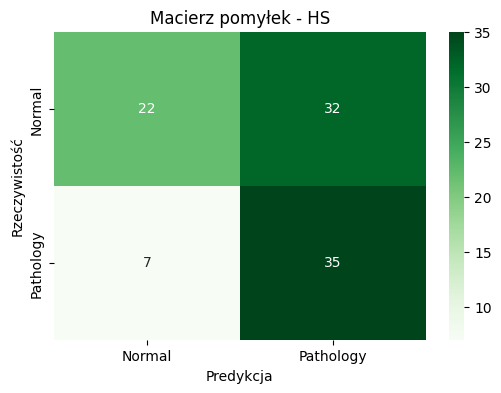

Ekstrakcja cech z csv_files/train_segmented.csv (source=LS)...
Ekstrakcja cech z csv_files/test_segmented.csv (source=LS)...

--- WYNIKI (LS) Drzewo Decyzyjne (Zoptymalizowane) ---
              precision    recall  f1-score   support

      Normal       0.94      0.70      0.81       135
   Pathology       0.35      0.79      0.49        28

    accuracy                           0.72       163
   macro avg       0.65      0.74      0.65       163
weighted avg       0.84      0.72      0.75       163



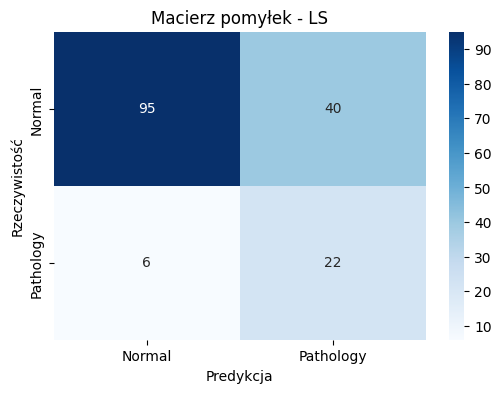

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

AUDIO_ROOT = "Sound_segmented"

def extract_features_from_csv(audio_root, csv_file, source_filter=None):
    df = pd.read_csv(csv_file)

    if source_filter is not None and "source" in df.columns:
        df = df[df["source"] == source_filter]

    features_list = []
    labels = []

    print(f"Ekstrakcja cech z {csv_file} (source={source_filter})...")

    for _, row in df.iterrows():
        file_path = os.path.join(audio_root, str(row["filename"]))

        try:
            y, sr = librosa.load(file_path, sr=None)
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
            
            if source_filter == "HS":
                m = np.mean(mfccs.T, axis=0)
                s = np.std(mfccs.T, axis=0)
                mi = np.min(mfccs.T, axis=0)
                ma = np.max(mfccs.T, axis=0)
                feat = np.hstack([m, s, mi, ma])
            else:
                feat = np.mean(mfccs.T, axis=0)
            
            features_list.append(feat)
            labels.append(int(row["label"]))
        except:
            continue

    return np.array(features_list), np.array(labels)


def train_and_eval(source_name):
    X_train, y_train = extract_features_from_csv(AUDIO_ROOT, "csv_files/train_segmented.csv", source_filter=source_name)
    X_test, y_test = extract_features_from_csv(AUDIO_ROOT, "csv_files/test_segmented.csv", source_filter=source_name)

    if source_name == "HS":
        clf = DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42)
    else:
        clf = DecisionTreeClassifier(max_depth=5, random_state=42)

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    print(f"\n--- WYNIKI ({source_name}) Drzewo Decyzyjne (Zoptymalizowane) ---")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Pathology"]))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    color = "Greens" if source_name == "HS" else "Blues"
    
    sns.heatmap(cm, annot=True, fmt="d", cmap=color,
                xticklabels=["Normal", "Pathology"],
                yticklabels=["Normal", "Pathology"])
    plt.title(f"Macierz pomyłek - {source_name}")
    plt.xlabel("Predykcja")
    plt.ylabel("Rzeczywistość")
    plt.show()

if __name__ == "__main__":
    train_and_eval("HS")
    train_and_eval("LS")

In [ ]:
import sys
print(sys.executable)
print(sys.version)

import os
import numpy as np
import pandas as pd
import librosa
from scipy.signal import butter, lfilter

BASE_PATH = os.getcwd()
CSV_DIR = os.path.join(BASE_PATH, "csv_files")
PLIKI_CSV = ["train_segmented.csv", "val_segmented.csv", "test_segmented.csv"]

PASMO = (100.0, 1500.0)
CECHY_COUNT = 20

def filtr_pasmo(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return lfilter(b, a, data)

def infer_modality(source, original_filename, segment_filename):
    # source: HS / LS / MIX
    if isinstance(source, str):
        s = source.strip().upper()
        if s in ("HS", "LS"):
            return s
        if s == "MIX":
            # Preferuj original_filename (np. "MIX/H0085.wav"), fallback na filename
            base = os.path.basename(str(original_filename) if pd.notna(original_filename) else str(filename)).strip()
            if len(base) > 0:
                first = base[0].upper()
                if first == "H":
                    return "HS"
                if first == "L":
                    return "LS"
    return None

def wyciagnij_mfcc(full_path, label):
    sygnal, fs = librosa.load(full_path, sr=4000)
    przefiltrowany = filtr_pasmo(sygnal, PASMO[0], PASMO[1], fs)
    mfccs = librosa.feature.mfcc(y=przefiltrowany, sr=fs, n_mfcc=CECHY_COUNT)

    wynik = {}
    for i in range(CECHY_COUNT):
        wynik[f"mfcc_mean_{i}"] = float(np.mean(mfccs[i]))
        wynik[f"mfcc_std_{i}"] = float(np.std(mfccs[i]))
    wynik["label"] = int(label)
    return wynik

for plik_csv in PLIKI_CSV:
    df = pd.read_csv(os.path.join(CSV_DIR, plik_csv))

    out_rows = []
    skipped_missing = 0
    skipped_modality = 0
    skipped_error = 0

    print(f"Przetwarzam: {plik_csv} ({len(df)} wierszy)")

    for _, row in df.iterrows():
        rel_seg = row.get("filename")
        if pd.isna(rel_seg):
            skipped_missing += 1
            continue

        # W *_segmented.csv 'filename' jest względne względem Sound_segmented
        full_path = os.path.join(BASE_PATH, "Sound_segmented", str(rel_seg))
        if not os.path.exists(full_path):
            skipped_missing += 1
            continue

        modality = infer_modality(
            source=row.get("source"),
            original_filename=row.get("original_filename"),
            filename=rel_seg,
        )
        if modality is None:
            skipped_modality += 1
            continue

        try:
            feats = wyciagnij_mfcc(full_path, row["label"])
            feats["modality"] = modality
            feats["source"] = row.get("source")
            feats["original_filename"] = row.get("original_filename")
            feats["filename"] = rel_seg
            out_rows.append(feats)
        except Exception:
            skipped_error += 1
            continue

    out_df = pd.DataFrame(out_rows)
    out_name = f"features_{plik_csv}"  # np. features_train_segmented.csv
    out_df.to_csv(os.path.join(BASE_PATH, out_name), index=False)

    print(
        f"Zapisano: {out_name} | ok={len(out_df)} "
        f"| brak_pliku={skipped_missing} | brak_modality={skipped_modality} | błąd={skipped_error}"
    )

print("Cechy wyeksportowane.")

c:\Users\Karol\AppData\Local\Programs\Python\Python314\python.exe
3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
Przetwarzam: train_segmented.csv (2621 wierszy)
Zapisano: features_train_segmented.csv | ok=2621 | brak_pliku=0 | brak_modality=0 | błąd=0
Przetwarzam: val_segmented.csv (372 wierszy)
Zapisano: features_val_segmented.csv | ok=372 | brak_pliku=0 | brak_modality=0 | błąd=0
Przetwarzam: test_segmented.csv (872 wierszy)
Zapisano: features_test_segmented.csv | ok=872 | brak_pliku=0 | brak_modality=0 | błąd=0
Cechy wyeksportowane.



=== MODALITY: HS | train=1299 test=264 ===
Uruchamiam GridSearchCV (cv=5)...
Statystyki klasyfikacji:
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95        54
   Pathology       1.00      0.98      0.99       210

    accuracy                           0.98       264
   macro avg       0.96      0.98      0.97       264
weighted avg       0.98      0.98      0.98       264



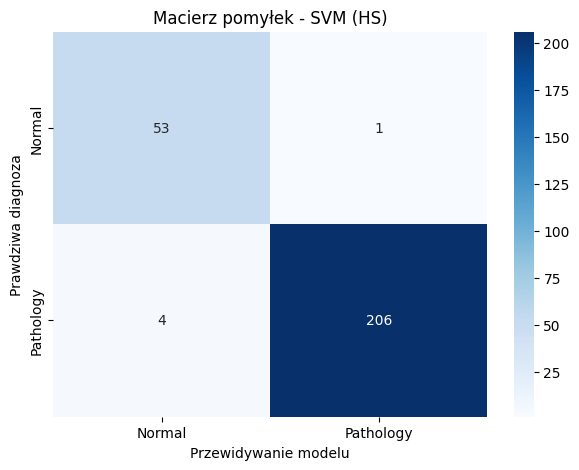


=== MODALITY: LS | train=1322 test=608 ===
Uruchamiam GridSearchCV (cv=5)...
Statystyki klasyfikacji:
              precision    recall  f1-score   support

      Normal       0.99      0.76      0.86       405
   Pathology       0.68      0.99      0.80       203

    accuracy                           0.84       608
   macro avg       0.83      0.87      0.83       608
weighted avg       0.89      0.84      0.84       608



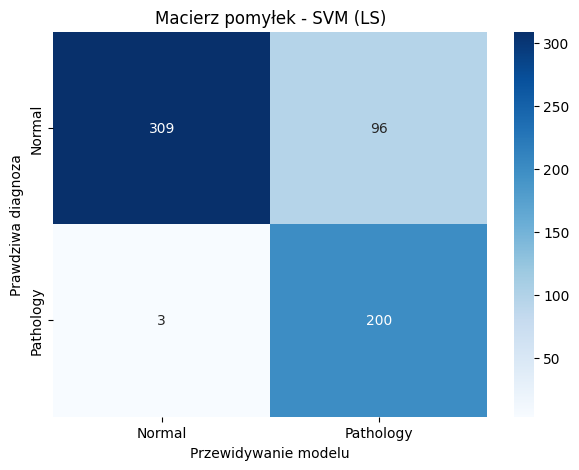

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

FOLDER = os.getcwd()

train_df = pd.read_csv(os.path.join(FOLDER, "features_train_segmented.csv"))
test_df  = pd.read_csv(os.path.join(FOLDER, "features_test_segmented.csv"))

feature_cols = [c for c in train_df.columns if c.startswith("mfcc_")]
if not feature_cols:
    raise ValueError("Nie znaleziono kolumn mfcc_ w features_*.csv")

label_names = ["Normal", "Pathology"]

for modality in ["HS", "LS"]:
    tr = train_df[train_df["modality"] == modality].copy()
    te = test_df[test_df["modality"] == modality].copy()

    print(f"\n=== MODALITY: {modality} | train={len(tr)} test={len(te)} ===")
    if len(tr) == 0 or len(te) == 0:
        print("Brak danych dla tej modality — pomijam.")
        continue

    X_train = tr[feature_cols]
    y_train = tr["label"].astype(int)

    X_test = te[feature_cols]
    y_test = te["label"].astype(int)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Bezpieczne CV: musi być >=2 i nie większe niż min liczności klasy
    class_counts = y_train.value_counts()
    min_count = int(class_counts.min()) if len(class_counts) > 0 else 0
    cv = min(5, min_count) if min_count >= 2 else None

    param_grid = {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.01],
        "kernel": ["rbf", "poly"],
    }

    if cv is None:
        print("Za mało próbek na GridSearchCV — trenuję domyślny SVC(rbf).")
        best_model = SVC(kernel="rbf", gamma="scale", C=1)
        best_model.fit(X_train_s, y_train)
        best_params = {"C": 1, "gamma": "scale", "kernel": "rbf"}
    else:
        print(f"Uruchamiam GridSearchCV (cv={cv})...")
        grid = GridSearchCV(SVC(), param_grid, cv=cv, verbose=0)
        grid.fit(X_train_s, y_train)
        best_model = grid.best_estimator_
        best_params = grid.best_params_

    y_pred = best_model.predict(X_test_s)

    print("Statystyki klasyfikacji:")
    print(classification_report(y_test, y_pred, labels=[0,1], target_names=label_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0,1])

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Macierz pomyłek - SVM ({modality})")
    plt.ylabel("Prawdziwa diagnoza")
    plt.xlabel("Przewidywanie modelu")

    out_png = os.path.join(FOLDER, f"macierz_pomylek_SVM_{modality}.png")
    plt.savefig(out_png, bbox_inches="tight")
    plt.show()

    out_txt = os.path.join(FOLDER, f"wyniki_svm_dokumentacja_{modality}.txt")
    with open(out_txt, "w", encoding="utf-8") as f:
        f.write(f"MODALITY: {modality}\n")
        f.write(f"Najlepsze parametry: {best_params}\n\n")
        f.write(classification_report(y_test, y_pred, labels=[0,1], target_names=label_names, zero_division=0))

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Katalog projektu (tam gdzie jest notebook)
PROJECT_ROOT = os.getcwd()
CSV_ROOT=os.path.join(PROJECT_ROOT,"csv_files")
AUDIO_ROOT = os.path.join(PROJECT_ROOT, "Sound_segmented")
OUT_ROOT = os.path.join(PROJECT_ROOT, "DANE_OBRAZOWE_CNN")

# Te pliki mają: modality + filename, więc idealnie pasują do podziału HS/LS
CSV_LIST = [
    "train_segmented.csv",
    "val_segmented.csv",
    "test_segmented.csv",
]

# Filtr Butterwortha rzędu 4 (pasmo 100–1500 Hz)
def dsp_filter(signal, fs):
    nyq = 0.5 * fs
    b, a = butter(4, [100 / nyq, 1500 / nyq], btype="band")
    return lfilter(b, a, signal)

def dataset_from_features_name(name: str) -> str:
    # np. features_train_segmented.csv -> train
    base = os.path.basename(name)
    base = base.replace("features_", "")
    return base.split("_")[0]

for csv_name in CSV_LIST:
    csv_path = os.path.join(CSV_ROOT, csv_name)
    if not os.path.exists(csv_path):
        print(f"Brak pliku: {csv_path}")
        continue

    data = pd.read_csv(csv_path)
    dataset = dataset_from_features_name(csv_name)
    print(f"\nGeneruję spektrogramy: {csv_name} -> dataset={dataset} (wierszy={len(data)})")

    if "filename" not in data.columns:
        raise ValueError(f"Brak kolumny 'filename' w {csv_name}")
    if "modality" not in data.columns:
        raise ValueError(f"Brak kolumny 'modality' (HS/LS) w {csv_name}")
    if "label" not in data.columns:
        raise ValueError(f"Brak kolumny 'label' w {csv_name}")

    saved = 0
    moved = 0
    skipped_exists = 0
    skipped_missing_wav = 0
    skipped_missing_modality = 0
    skipped_error = 0

    for _, row in data.iterrows():
        rel_wav = row.get("filename")
        if pd.isna(rel_wav):
            skipped_missing_wav += 1
            continue

        rel_wav = str(rel_wav).replace("/", os.sep)
        wav_path = os.path.join(AUDIO_ROOT, rel_wav)
        if not os.path.exists(wav_path):
            skipped_missing_wav += 1
            continue

        modality = row.get("modality")
        if pd.isna(modality) or str(modality).strip() == "":
            skipped_missing_modality += 1
            continue
        modality_dir = str(modality).strip().upper()
        if modality_dir not in ("HS", "LS"):
            # jakby trafiło się coś nietypowego, wrzucamy do "UNK"
            modality_dir = "UNK"

        label_dir = str(int(row.get("label"))) if pd.notna(row.get("label")) else "UNK"
        base = os.path.splitext(os.path.basename(wav_path))[0]

        # Docelowa struktura: dataset/modality/label/xxx.png
        save_dir = os.path.join(OUT_ROOT, dataset, modality_dir, label_dir)
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{base}.png")

        # Migracja z poprzedniej struktury (dataset/label/xxx.png), jeśli istnieje
        legacy_path = os.path.join(OUT_ROOT, dataset, label_dir, f"{base}.png")
        if not os.path.exists(save_path) and os.path.exists(legacy_path):
            try:
                os.replace(legacy_path, save_path)
                moved += 1
                continue
            except Exception:
                pass

        if os.path.exists(save_path):
            skipped_exists += 1
            continue

        try:
            audio, sr = librosa.load(wav_path, sr=4000)
            filtered = dsp_filter(audio, sr)

            stft_data = librosa.stft(filtered)
            db_data = librosa.amplitude_to_db(np.abs(stft_data), ref=np.max)

            plt.figure(figsize=(4, 4))
            librosa.display.specshow(db_data, sr=sr)
            plt.axis("off")
            plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
            plt.close()
            saved += 1
        except Exception:
            plt.close("all")
            skipped_error += 1
            continue

    print(
        f"Zapisano={saved} | przeniesiono={moved} | już_istnieje={skipped_exists} "
        f"| brak_wav={skipped_missing_wav} | brak_modality={skipped_missing_modality} | błąd={skipped_error}\n"
        f"Wyjście: {os.path.abspath(os.path.join(OUT_ROOT, dataset))}"
    )


Generuję spektrogramy: train_segmented.csv -> dataset=train (wierszy=2621)
Zapisano=0 | przeniesiono=0 | już_istnieje=2621 | brak_wav=0 | brak_modality=0 | błąd=0
Wyjście: c:\Users\Karol\Desktop\Analiza_HLS-CMDS\DANE_OBRAZOWE_CNN\train

Generuję spektrogramy: val_segmented.csv -> dataset=val (wierszy=372)
Zapisano=0 | przeniesiono=0 | już_istnieje=372 | brak_wav=0 | brak_modality=0 | błąd=0
Wyjście: c:\Users\Karol\Desktop\Analiza_HLS-CMDS\DANE_OBRAZOWE_CNN\val

Generuję spektrogramy: test_segmented.csv -> dataset=test (wierszy=872)
Zapisano=0 | przeniesiono=0 | już_istnieje=872 | brak_wav=0 | brak_modality=0 | błąd=0
Wyjście: c:\Users\Karol\Desktop\Analiza_HLS-CMDS\DANE_OBRAZOWE_CNN\test




MODALITY: HS
Ładowanie danych z CSV -> DANE_OBRAZOWE_CNN...
[HS | train_segmented.csv] użyte próbek: 1299 | split=train
[HS | val_segmented.csv] użyte próbek: 242 | split=val
[HS | test_segmented.csv] użyte próbek: 264 | split=test


c:\Users\Karol\Desktop\Analiza_HLS-CMDS\.conda\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 123008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   125,961,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,031,969 (480.77 MB)

 Trainable params: 126,031,969 (480.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5989 - loss: 2.2191 - val_accuracy: 0.5950 - val_loss: 0.6226
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7421 - loss: 0.5116 - val_accuracy: 0.7934 - val_loss: 0.5021
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8322 - loss: 0.3597 - val_accuracy: 0.8802 - val_loss: 0.2943
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8907 - loss: 0.2649 - val_accuracy: 0.9091 - val_loss: 0.1842
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9076 - loss: 0.2131 - val_accuracy: 0.9008 - val_loss: 0.2425
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9692 - loss: 0.0783 - val_accuracy: 0.9628 - val_loss: 0.0974
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9915 - loss: 0.0333 - val_accuracy: 0.9215 - val_loss: 0.1939
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9938 - loss: 0.0221 - val_accuracy: 0.9587 - val_loss:

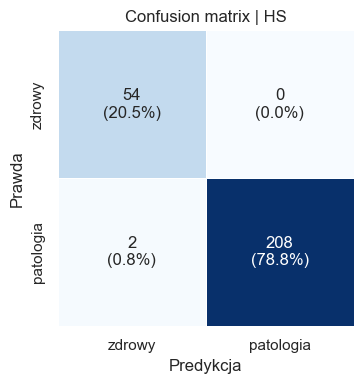


MODALITY: LS
Ładowanie danych z CSV -> DANE_OBRAZOWE_CNN...
[LS | train_segmented.csv] użyte próbek: 1322 | split=train
[LS | val_segmented.csv] użyte próbek: 130 | split=val
[LS | test_segmented.csv] użyte próbek: 608 | split=test


c:\Users\Karol\Desktop\Analiza_HLS-CMDS\.conda\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 123008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   125,961,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,031,969 (480.77 MB)

 Trainable params: 126,031,969 (480.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6150 - loss: 2.3676 - val_accuracy: 0.7769 - val_loss: 0.5501
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 998ms/step - accuracy: 0.7890 - loss: 0.4561 - val_accuracy: 0.9538 - val_loss: 0.2481
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8926 - loss: 0.2695 - val_accuracy: 0.9923 - val_loss: 0.0918
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 991ms/step - accuracy: 0.9425 - loss: 0.1573 - val_accuracy: 0.9846 - val_loss: 0.0732
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9592 - loss: 0.1245 - val_accuracy: 0.9923 - val_loss: 0.0675
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9803 - loss: 0.0606 - val_accuracy: 0.8000 - val_loss: 0.5125
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9909 - loss: 0.0402 - val_accuracy: 0.9923 - val_loss: 0.0234
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9769 - val

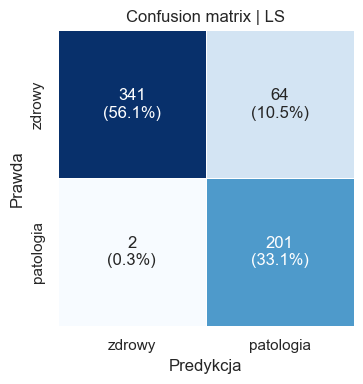

In [ ]:
import os
import subprocess
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

np.random.seed(123)
tf.random.set_seed(123)

PROJECT_ROOT = os.getcwd()
CSV_ROOT = os.path.join(PROJECT_ROOT, "csv_files")
IMG_ROOT = os.path.join(PROJECT_ROOT, "DANE_OBRAZOWE_CNN")

IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 32
EPOCHS = 10  # zmień np. na 3 jeśli ma być szybciej

CLASS_NAMES = ["zdrowy", "patologia"]  # 0 -> zdrowy, 1 -> patologia

def split_from_csv_name(csv_name: str) -> str:
    # train_segmented.csv -> train
    return os.path.basename(csv_name).split("_")[0]

def png_path_from_row(split: str, row: pd.Series) -> str:
    wav_rel = str(row["filename"])
    base = os.path.splitext(os.path.basename(wav_rel))[0] + ".png"
    modality = str(row["modality"]).strip().upper()
    label = str(int(row["label"]))
    return os.path.join(IMG_ROOT, split, modality, label, base)

def load_split_dataset(csv_name: str, shuffle: bool, modality: str) -> tf.data.Dataset:
    """Wczytuje TF dataset dla konkretnej modality: 'HS' albo 'LS'."""
    csv_path = os.path.join(CSV_ROOT, csv_name)
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Nie znaleziono CSV: {csv_path}")

    split = split_from_csv_name(csv_name)
    df = pd.read_csv(csv_path)

    required = {"filename", "label", "modality"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Brak kolumn w {csv_name}: {sorted(missing)}")

    modality = str(modality).strip().upper()
    if modality not in ("HS", "LS"):
        raise ValueError("modality musi być 'HS' albo 'LS'")

    df = df[df["modality"].astype(str).str.upper() == modality].copy()

    # Ścieżki do PNG + etykiety
    paths = [png_path_from_row(split, r) for _, r in df.iterrows()]
    labels = df["label"].astype(int).to_numpy()

    # Szybka walidacja: ile plików brakuje
    exists_mask = np.array([os.path.exists(p) for p in paths], dtype=bool)
    missing_count = int((~exists_mask).sum())
    if missing_count > 0:
        paths = list(np.array(paths, dtype=object)[exists_mask])
        labels = labels[exists_mask]
        print(f"[{modality} | {csv_name}] Brakujących PNG: {missing_count} (pominięte)")

    print(f"[{modality} | {csv_name}] użyte próbek: {len(paths)} | split={split}")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 5000), seed=123, reshuffle_each_iteration=True)

    def _load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
        img = tf.cast(img, tf.float32)  # rescaling w modelu
        label = tf.cast(label, tf.int32)
        return img, label

    ds = ds.map(_load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def build_model() -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1.0 / 255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        tf.keras.layers.Conv2D(16, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1024, activation="relu"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def predict_labels(model: tf.keras.Model, ds: tf.data.Dataset, threshold: float = 0.5):
    y_true = np.concatenate([y.numpy().reshape(-1) for _, y in ds], axis=0)
    y_prob = model.predict(ds, verbose=0).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)
    return y_true, y_pred

def plot_confusion_matrix(cm: np.ndarray, title: str):
    cm = np.asarray(cm, dtype=int)
    total = int(cm.sum()) if int(cm.sum()) else 1
    annot = np.array([[f"{v}\n({v/total:.1%})" for v in row] for row in cm])

    plt.figure(figsize=(5, 4))
    ax = sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    ax.set_xlabel("Predykcja")
    ax.set_ylabel("Prawda")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# --- 2 pętle: HS i LS ---
for modality in ["HS", "LS"]:
    tf.keras.backend.clear_session()
    print("\n" + "=" * 60)
    print(f"MODALITY: {modality}")
    print("Ładowanie danych z CSV -> DANE_OBRAZOWE_CNN...")
    train_ds = load_split_dataset("train_segmented.csv", shuffle=True, modality=modality)
    val_ds   = load_split_dataset("val_segmented.csv", shuffle=False, modality=modality)
    test_ds  = load_split_dataset("test_segmented.csv", shuffle=False, modality=modality)

    model = build_model()
    model.summary()

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"Test accuracy ({modality}):", float(test_acc))

    y_true, y_pred = predict_labels(model, test_ds)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=[0, 1], target_names=CLASS_NAMES, digits=4))
    plot_confusion_matrix(cm, title=f"Confusion matrix | {modality}")

Wczytano:
- train: X=(2621, 40), y=(2621,)
- val:   X=(372, 40), y=(372,)
- test:  X=(872, 40), y=(872,)

Najlepsze k (na walidacji): 11 | val accuracy=0.9113
Top 10 k na walidacji:
  k=11  acc=0.9113
  k= 5  acc=0.8978
  k=13  acc=0.8978
  k=17  acc=0.8978
  k=15  acc=0.8952
  k=19  acc=0.8952
  k= 9  acc=0.8898
  k= 3  acc=0.8871
  k= 7  acc=0.8844
  k=25  acc=0.8817

=== MojKNN (test) ===
Accuracy: 0.8772935779816514
Confusion matrix:
 [[389  70]
 [ 37 376]]

=== sklearn KNeighborsClassifier (test) ===
Accuracy: 0.8772935779816514
Confusion matrix:
 [[389  70]
 [ 37 376]]

Classification report:
               precision    recall  f1-score   support

           0     0.9131    0.8475    0.8791       459
           1     0.8430    0.9104    0.8754       413

    accuracy                         0.8773       872
   macro avg     0.8781    0.8790    0.8773       872
weighted avg     0.8799    0.8773    0.8774       872


Zgodność Twojego MojKNN ze sklearn: 100.00%


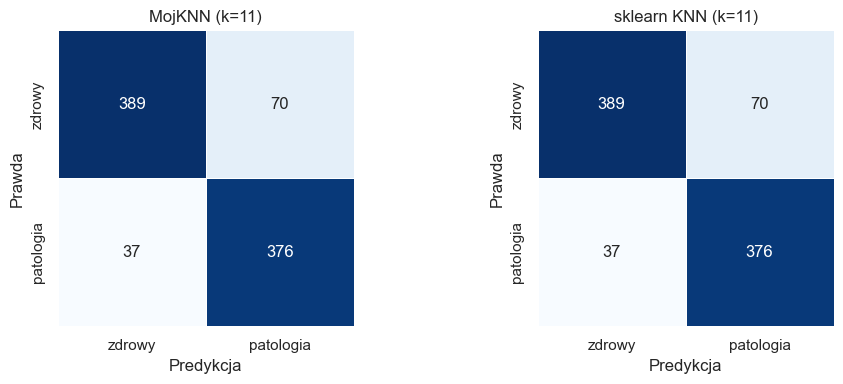

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

def odleglosc_euklidesowa(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


class MojKNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)

    def predict(self, X):
        X = np.asarray(X)
        przewidziane_klasy = [self._przewidz_pojedynczy(x) for x in X]
        return np.array(przewidziane_klasy)

    def _przewidz_pojedynczy(self, x):
        odleglosci = [odleglosc_euklidesowa(x, x_train) for x_train in self.X_train]
        k_indeksy = np.argsort(odleglosci)[: self.k]
        k_najblizsze_klasy = [self.y_train[i] for i in k_indeksy]
        najczestsza = Counter(k_najblizsze_klasy).most_common(1)
        return int(najczestsza[0][0])


def plot_cm_ax(cm, ax, labels=("zdrowy", "patologia"), title="Confusion matrix"):
    cm = np.asarray(cm)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predykcja")
    ax.set_ylabel("Prawda")
    ax.set_title(title)


def wczytaj_cechy_csv(sciezka_csv: str):
    """
    Wczytuje plik z cechami (np. features_test_segmented.csv).
    Oczekuje kolumny 'label' (0/1).
    Zwraca: X (numeryczne cechy), y (etykiety), df (całość).
    """
    df = pd.read_csv(sciezka_csv)
    if "label" not in df.columns:
        raise ValueError(f"Brak kolumny 'label' w pliku: {sciezka_csv}")

    y = df["label"].astype(int).to_numpy()

    # Zostawiamy tylko kolumny numeryczne (oprócz label)
    X_df = df.drop(columns=["label"], errors="ignore")
    X_df = X_df.select_dtypes(include=["number"])
    X = X_df.to_numpy(dtype=float)

    return X, y, df


# --- ŚCIEŻKI DO TWOICH DANYCH (segmented) ---
ROOT = Path(".").resolve()
TRAIN_CSV = ROOT / "features_train_segmented.csv"
VAL_CSV = ROOT / "features_val_segmented.csv"
TEST_CSV = ROOT / "features_test_segmented.csv"

for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Nie znaleziono pliku: {p}")

X_train, y_train, df_train = wczytaj_cechy_csv(str(TRAIN_CSV))
X_val, y_val, df_val = wczytaj_cechy_csv(str(VAL_CSV))
X_test, y_test, df_test = wczytaj_cechy_csv(str(TEST_CSV))

print("Wczytano:")
print(f"- train: X={X_train.shape}, y={y_train.shape}")
print(f"- val:   X={X_val.shape}, y={y_val.shape}")
print(f"- test:  X={X_test.shape}, y={y_test.shape}")

# --- DOBÓR k NA WALIDACJI ---
# k-NN jest bardzo czuły na skalę cech -> standaryzacja (skalujemy na train, oceniamy na val)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

# Szukamy po nieparzystych k (mniej remisów). Ograniczamy do liczby próbek w train.
max_k = min(51, len(y_train))
k_values = [k for k in range(1, max_k + 1, 2) if k >= 1]

wyniki = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    pred_val = model.predict(X_val_s)
    acc_val = accuracy_score(y_val, pred_val)
    wyniki.append((k, acc_val))

# wybór najlepszego k: największa accuracy, a przy remisie mniejsze k
wyniki_sorted = sorted(wyniki, key=lambda t: (-t[1], t[0]))
BEST_K, BEST_VAL_ACC = wyniki_sorted[0]
print(f"\nNajlepsze k (na walidacji): {BEST_K} | val accuracy={BEST_VAL_ACC:.4f}")
print("Top 10 k na walidacji:")
for k, acc in wyniki_sorted[:10]:
    print(f"  k={k:2d}  acc={acc:.4f}")

#TESTUJEMY MODELE NA TEST 
# Uwaga: do finalnego testu trenujemy na (train+val), więc refitujemy scaler na (train+val).
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

scaler_final = StandardScaler()
X_trainval_s = scaler_final.fit_transform(X_trainval)
X_test_s = scaler_final.transform(X_test)

RUN_CUSTOM = True  # ustaw na False, jeśli będzie za wolno
if RUN_CUSTOM:
    moj_model = MojKNN(k=BEST_K)
    moj_model.fit(X_trainval_s, y_trainval)
    moje_wyniki = moj_model.predict(X_test_s)
    cm_moj = confusion_matrix(y_test, moje_wyniki)
    print("\n=== MojKNN (test) ===")
    print("Accuracy:", accuracy_score(y_test, moje_wyniki))
    print("Confusion matrix:\n", cm_moj)

pro_model = KNeighborsClassifier(n_neighbors=BEST_K)
pro_model.fit(X_trainval_s, y_trainval)
pro_wyniki = pro_model.predict(X_test_s)
cm_sklearn = confusion_matrix(y_test, pro_wyniki)

print("\n=== sklearn KNeighborsClassifier (test) ===")
print("Accuracy:", accuracy_score(y_test, pro_wyniki))
print("Confusion matrix:\n", cm_sklearn)
print("\nClassification report:\n", classification_report(y_test, pro_wyniki, digits=4))

if RUN_CUSTOM:
    zgodnosc = np.mean(moje_wyniki == pro_wyniki) * 100
    print(f"\nZgodność Twojego MojKNN ze sklearn: {zgodnosc:.2f}%")

#CONFUSION MATRIX
labels = ["zdrowy", "patologia"]
if RUN_CUSTOM:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plot_cm_ax(cm_moj, axes[0], labels=labels, title=f"MojKNN (k={BEST_K})")
    plot_cm_ax(cm_sklearn, axes[1], labels=labels, title=f"sklearn KNN (k={BEST_K})")
else:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    plot_cm_ax(cm_sklearn, ax, labels=labels, title=f"sklearn KNN (k={BEST_K})")

plt.tight_layout()
plt.show()